# Superdense Coding with Qiskit

## Importing necessary libraries 

In [2]:
import math
from pandas import DataFrame as df
import numpy as np

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_bloch_vector, plot_histogram, plot_bloch_multivector, plot_state_city, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_aer import Aer

from qiskit.quantum_info import Statevector, Operator

In [3]:
from qiskit.visualization import array_to_latex
from qiskit.circuit.library import Initialize
from qiskit.quantum_info import random_statevector

## Functions for Superdense Coding Protocol

In [4]:
# Define a function that takes a QuantumCircuit (qc) 
# and two integers (a & b)
def create_bell_pair(qc, a, b):
    qc.h(a) # Apply a h-gate to the first qubit
    qc.cx(a,b) # Apply a CNOT, using the first qubit as the control

In [5]:
# Define a function that takes a QuantumCircuit (qc)
# a qubit index (qubit) and a message string (msg)
def encode_message(qc, qubit, msg):
    if msg == "00":
        pass    # To send 00 we do nothing
    elif msg == "10":
        qc.x(qubit) # To send 10 we apply an X-gate
    elif msg == "01":
        qc.z(qubit) # To send 01 we apply a Z-gate
    elif msg == "11":
        qc.z(qubit) # To send 11, we apply a Z-gate
        qc.x(qubit) # followed by an X-gate
    else:
        print("Invalid Message: Sending '00'")

In [6]:
def decode_message(qc, a, b):
    qc.cx(a,b)
    qc.h(a)

## Drawing the Superdense Coding Circuit

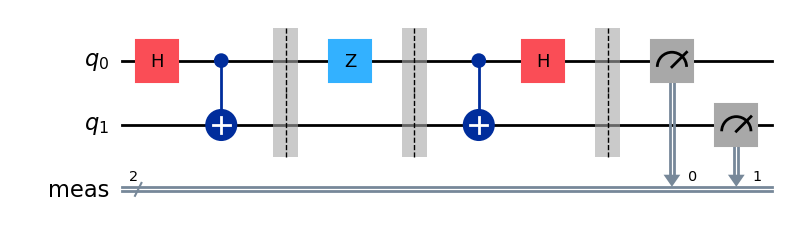

In [7]:
# Create the quantum circuit with 2 qubits
qc = QuantumCircuit(2)


# First, Charlie creates the entangled pair between Alice and Bob
create_bell_pair(qc, 0, 1)
qc.barrier() # This adds a barrier to our circuit. A barrier 
             # separates the gates in our diagram and makes it 
             # clear which part of the circuit is which

# At this point, qubit 0 goes to Alice and qubit 1 goes to Bob

# Next, Alice encodes her message onto qubit 0. In this case,
# we want to send the message '10'. You can try changing this
# value and see how it affects the circuit
message = "01"
encode_message(qc, 0, message)
qc.barrier()
# Alice then sends her qubit to Bob.

# After recieving qubit 0, Bob applies the recovery protocol:
decode_message(qc, 0, 1)

# Finally, Bob measures his qubits to read Alice's message
qc.measure_all()

# Draw our output
qc.draw('mpl')

## Executing the Superdense Coding Circuit 


Total Counts are: {'01': 1000}


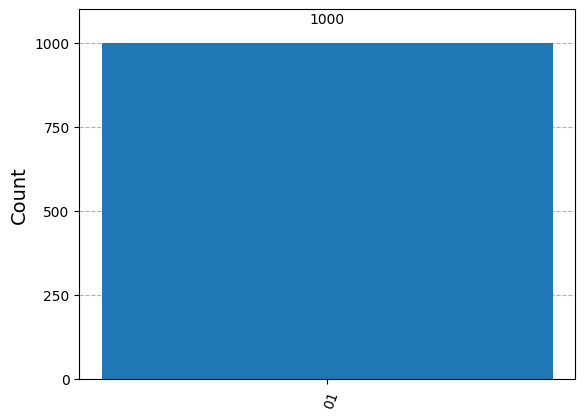

In [9]:
backend = Aer.get_backend('qasm_simulator') 

qct = transpile(qc, backend)
result = backend.run(qct, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)